# Pipelines and Hyperparameter Tuning

## Binary Classification — Breast Cancer Dataset

### Objective

Predict whether a tumor is malignant (1) or benign (0) using patient features.


This dataset has a tabular structure. Each row represents a tumor sample, and each column represents a numeric measurement extracted from a medical image of a breast mass:

- Features: 30 numeric attributes (e.g., mean radius, texture, area, smoothness, symmetry).

- Samples: 569 tumors.

- Target: Binary; 0 = malignant, 1 = benign

In [47]:
# 1. Import libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [48]:
# 2. Load dataset

data = load_breast_cancer()
X = data.data
y = data.target

print("Feature shape:", X.shape)
print("Target labels:", np.unique(y), data.target_names)

Feature shape: (569, 30)
Target labels: [0 1] ['malignant' 'benign']


In [49]:
# 3. Split data into train (70%) and test (30%) using stratified sampling

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)


In [50]:
# 4. Scale data using standardization method

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [51]:
# 5. Load and Train KNN Classifier

k = 7
knn_clf = KNeighborsClassifier(n_neighbors=k, )
knn_clf.fit(X_train_scaled, y_train)

,n_neighbors,7
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [52]:
# 6. Generate model predictions

y_pred_train = knn_clf.predict(X_train_scaled)
y_pred_test = knn_clf.predict(X_test_scaled)

In [53]:
# 7. Evaluate model
train_acc = accuracy_score(y_train, y_pred_train)
test_acc = accuracy_score(y_test, y_pred_test)
print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

train_cm = confusion_matrix(y_train, y_pred_train)
test_cm = confusion_matrix(y_test, y_pred_test)

Train Accuracy: 0.9723618090452262
Test Accuracy: 0.9649122807017544


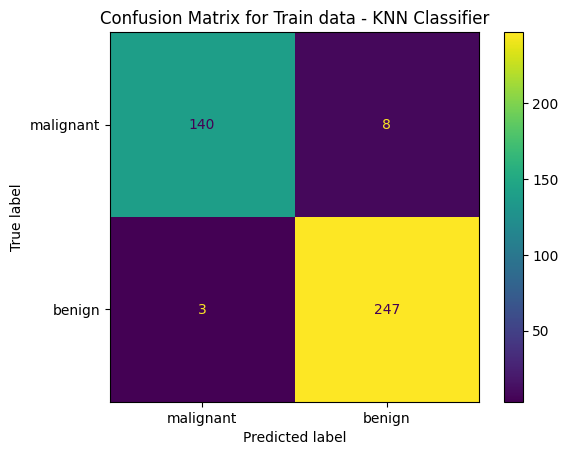

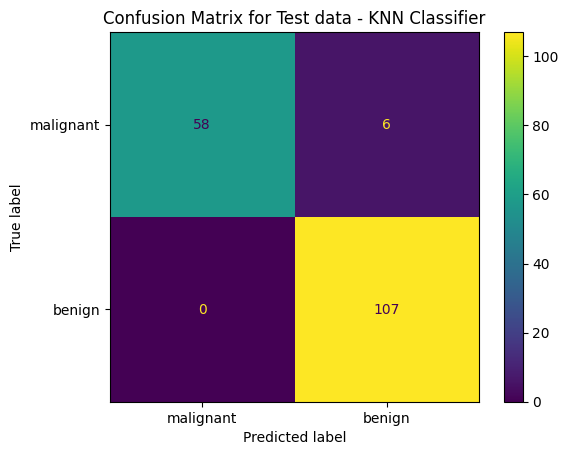

In [54]:
# 8.1. Plot confusion matrix for train data
disp = ConfusionMatrixDisplay(confusion_matrix=train_cm, display_labels=data.target_names)
disp.plot(cmap='viridis', values_format='d')
plt.title("Confusion Matrix for Train data - KNN Classifier")
plt.show()

# 8.2. Plot confusion matrix for test data
disp = ConfusionMatrixDisplay(confusion_matrix=test_cm, display_labels=data.target_names)
disp.plot(cmap='viridis', values_format='d')
plt.title("Confusion Matrix for Test data - KNN Classifier")
plt.show()

In [55]:
# 9. Hyperparamter Tuning: 
# Use different k values (from 1 to 20): train a new KNN at each time, then compute the test accuracy


acc_scores = []
k_values = range(1, 21)


for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred_test = knn.predict(X_test_scaled)
    test_acc = accuracy_score(y_test, y_pred_test)
    acc_scores.append(test_acc)



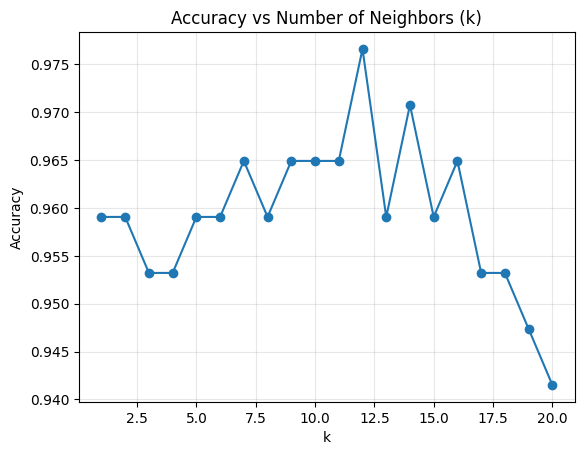

In [56]:
# 10. plot the accuracy with respect to the number of neighbors k


plt.plot(k_values, acc_scores, marker='o')
plt.title("Accuracy vs Number of Neighbors (k)")
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.grid(alpha=0.3)
plt.show()

What's the best K values based on the graph results?

The best number of neighbors is k=12 because it corresponds to the highest acc=0.977.

## Regression — Insurance Charges Dataset

### Objective

Predict medical insurance charges based on factors like age, BMI, and smoking status.

This dataset has a tabular structure:

- Samples: 1338.

- Features: 7 (3 numeric and 3 categorical).

- Target variable: charges.

- It has no missing values.



In [57]:
# 1. Import libraries

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

In [58]:
# 2. Load dataset

url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
df = pd.read_csv(url)
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [59]:
# 3. Split into features and target

X = df.drop(columns='charges')
y = df['charges']

In [60]:
# 4. Identify numeric and categorical columns

num_cols = X.select_dtypes(include='number').columns
cat_cols = X.select_dtypes(exclude='number').columns

In [61]:
# 5. Preprocessing: scale numeric, encode categorical

# 5.1. Define a transformer to scale numerical variables 
numeric_transformer = StandardScaler()

# 5.2. Define a transformer to encode categorical variables
categorical_transformer = OneHotEncoder(drop='first') # when we have only 2 categories, we need to remove one column because it has redundant info

# 5.3. Apply both transformers
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ]
)

In [ ]:
# 6. Load KNN regressor

k = 7
Knn_model = KNeighborsRegressor(n_neighbors=k)

In [63]:
# 7. Create KNN regression pipeline


knn_reg = Pipeline([
    ('prep', preprocessor),
    ('model', Knn_model)
])


In [64]:
# 8. Split data into train (70%) and test (30%)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [65]:
# 9. Train model

knn_reg.fit(X_train, y_train)

,steps,"[('prep', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [66]:
# 10. Generate model predictions

y_pred_train = knn_reg.predict(X_train)
y_pred_test = knn_reg.predict(X_test)

In [67]:
# 11. Evaluate model using RMSE, MAE, and R^2

train_rmse = root_mean_squared_error(y_train, y_pred_train)
train_mae = mean_absolute_error(y_train, y_pred_train)
train_r2 = r2_score(y_train, y_pred_train)


test_rmse = root_mean_squared_error(y_test, y_pred_test)
test_mae = mean_absolute_error(y_test, y_pred_test)
test_r2 = r2_score(y_test, y_pred_test)


print("Train RMSE:", train_rmse)
print("Train MAE:", train_mae)
print("Train R²:", train_r2)

print("Test RMSE:", test_rmse)
print("Test MAE:", test_mae)
print("Test R²:", test_r2)

Train RMSE: 4761.7071135300175
Train MAE: 2584.7205950035614
Train R²: 0.8451962630000971
Test RMSE: 6374.052197337706
Test MAE: 3732.1954615199006
Test R²: 0.7229071905067572


In [68]:
# 12. Hyperparamter Tuning: 
# Use different k values (from 1 to 20): train a new KNN at each time, then compute the test R^2

r2_scores = []
k_values = range(1, 21)

for k in k_values:
    Knn_model = KNeighborsRegressor(n_neighbors=k)

    model = Pipeline([
        ('prep', preprocessor),
        ('model', Knn_model)
    ])

    model.fit(X_train, y_train)
    y_pred_test = model.predict(X_test)
    test_r2 = r2_score(y_test, y_pred_test)
    r2_scores.append(test_r2)


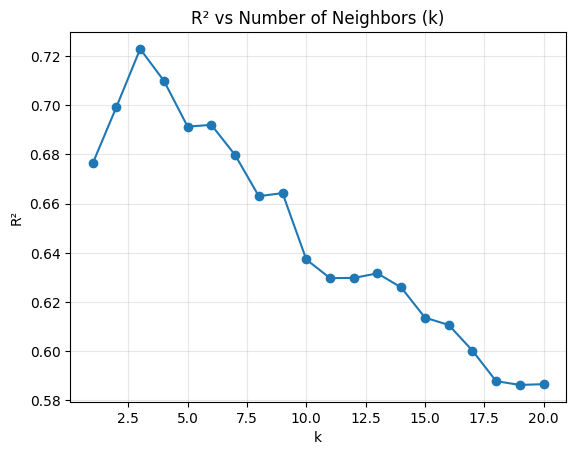

In [69]:
# 13. plot the R^2 with respect to the number of neighbors k


plt.plot(k_values, r2_scores, marker='o')
plt.title("R² vs Number of Neighbors (k)")
plt.xlabel("k")
plt.ylabel("R²")
plt.grid(alpha=0.3)
plt.show()


What's the best K values based on the graph results?

The best number of neighbors is k=3 because it corresponds to the highest R2=0.725.